# Smart Contract HGNN: Step-by-Step Training Notebook

This notebook mirrors the project pipeline described in `README.md`, `PLAN.md`, `ARCHITECTURE.md`, and `Hypergraph_Analysis.tex`.

It is organized in two parts:

1. **Walk through one contract** from Steps 1-6:
   - extract AST / CFG / call graph
   - build the dependency graph
   - construct node sets
   - compute node features
   - build hyperedges and the incidence matrix
   - run one HGNN forward pass
2. **Run Step 7 training** with 3-fold cross-validation using either:
   - preprocessed folds from `data/processed_dataset.pt`, or
   - on-the-fly preprocessing through the existing pipeline

This notebook is intended to be educational first, then usable for experiments.

## 0. Setup

In [1]:
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

# Make the repo root importable whether the notebook is launched from
# the project root or from notebooks/.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Project root: {PROJECT_ROOT}")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Project root: /home/pollmix/Coding/smart-contract-hgnn
Device: cuda
GPU: NVIDIA GeForce RTX 2080 SUPER


In [2]:
from src.extraction.ast_cfg import extract_all
from src.extraction.gdep import build_gdep
from src.hypergraph.nodeset import build_node_sets
from src.hypergraph.features import FEATURE_DIM, build_feature_matrix, get_feature_config
from src.hypergraph.hyperedges import build_hyperedges
from src.model.hgnn import HGNN
from src.evaluation.train import (
    generate_cv_splits,
    process_contract_list,
    compute_metrics,
    compute_class_weights,
)

print(f"FEATURE_DIM = {FEATURE_DIM}")
feature_config = get_feature_config()
feature_config

FEATURE_DIM = 34


{'feature_dim': 34,
 'func_features': {'offset': 0,
  'size': 9,
  'visibility_classes': ['public', 'private', 'internal', 'external'],
  'mutability_classes': ['pure', 'view', 'payable', 'nonpayable']},
 'state_var_features': {'offset': 9,
  'size': 14,
  'type_categories': ['uint',
   'address',
   'bool',
   'bytes',
   'mapping',
   'array',
   'struct',
   'other'],
  'access_patterns': ['read_only', 'write_only', 'read_write'],
  'reentrancy_flags': ['written_after_call', 'read_before_call']},
 'call_site_features': {'offset': 23,
  'size': 11,
  'call_opcodes': ['call', 'delegatecall', 'staticcall', 'other'],
  'reentrancy_flags': ['value_transfer',
   'gas_forwarded',
   'sender_controlled_target',
   'guarded_by_modifier'],
  'reentrancy_counts': ['writes_after_call_count_log',
   'reads_after_call_count_log',
   'reads_before_call_count_log']}}

## 1. Pick One Contract For The Walkthrough

By default, the notebook takes the first reentrant contract from the aggregated benchmark.

In [3]:
folds = generate_cv_splits(n_splits=3, random_state=42)

sample_sol_path = None
sample_label = None
for path, label in folds[0]["train"]:
    if label == 1:
        sample_sol_path = path
        sample_label = label
        break

print("Sample contract:", sample_sol_path)
print("Contract label:", sample_label, "(1 = vulnerable, 0 = safe)")

Sample contract: /home/pollmix/Coding/smart-contract-hgnn/src/evaluation/../../data/reentrancy-detection-benchmarks/benchmarks/aggregated-benchmark/src/reentrant/0ddd1c046d2a572672c87f87e287a176_cgt.sol
Contract label: 1 (1 = vulnerable, 0 = safe)


## 2. Step 1: AST, CFG, Call Graph Extraction

In [4]:
sample = extract_all(sample_sol_path, contract_label=sample_label)
if sample is None:
    raise RuntimeError("Extraction failed. Check solc/slither setup and dataset availability.")

print("Functions:", len(sample["functions"]))
print("State vars:", len(sample["state_vars"]))
print("Call sites:", len(sample["call_sites"]))
print("Call graph nodes:", sample["G_call"].number_of_nodes())
print("Call graph edges:", sample["G_call"].number_of_edges())
print("CFG functions:", len(sample["cfg"]))

# Per-call-site labels come from Slither's reentrancy detectors
# (Section 6.2 revised). Safe contracts get all zeros.
cs_labels = sample.get("call_site_labels", {})
label_info = sample.get("label_info", {})
print("Call-site labels:", cs_labels)
print("Label info:", label_info)

Functions: 42
State vars: 36
Call sites: 8
Call graph nodes: 42
Call graph edges: 3
CFG functions: 42
Call-site labels: {'call:withdrawFunds_re_ent17:24': 1, 'call:withdrawFunds_re_ent3:44': 1, 'call:buyTicket_re_ent9:59': 1, 'call:bug_re_ent13:89': 1, 'call:withdrawBalance_re_ent26:136': 1, 'call:withdraw_balances_re_ent8:262': 1, 'call:withdrawBalance_re_ent40:330': 1, 'call:withdrawBalance_re_ent33:358': 1}
Label info: {'contract_label': 1, 'flagged_by_slither': ['call:bug_re_ent13:89', 'call:buyTicket_re_ent9:59', 'call:withdrawBalance_re_ent26:136', 'call:withdrawBalance_re_ent33:358', 'call:withdrawBalance_re_ent40:330', 'call:withdrawFunds_re_ent17:24', 'call:withdrawFunds_re_ent3:44', 'call:withdraw_balances_re_ent8:262'], 'fallback_used': False}


In [5]:
pd.DataFrame(sample["functions"]).head(10)

,name,visibility,mutability,is_constructor
0,buyTicket_re_ent2,public,nonpayable,False
1,withdrawFunds_re_ent17,public,nonpayable,False
2,buyTicket_re_ent37,public,nonpayable,False
3,withdrawFunds_re_ent3,public,nonpayable,False
4,buyTicket_re_ent9,public,nonpayable,False
5,claimReward_re_ent25,public,nonpayable,False
6,withdrawFunds_re_ent31,public,nonpayable,False
7,bug_re_ent13,public,nonpayable,False
8,constructor,public,nonpayable,True
9,withdrawBalance_re_ent19,public,nonpayable,False


In [6]:
pd.DataFrame(sample["call_sites"]).head(10)

,function,line,call_type,opcode,has_value,gas_forwarded,sender_controlled_target,guarded_by_modifier,reads_before_call,reads_after_call,writes_after_call
0,withdrawFunds_re_ent17,24,low_level,call,True,True,True,False,[balances_re_ent17],[balances_re_ent17],[balances_re_ent17]
1,withdrawFunds_re_ent3,44,low_level,call,True,True,True,False,[balances_re_ent3],[balances_re_ent3],[balances_re_ent3]
2,buyTicket_re_ent9,59,low_level,call,True,True,False,False,[],[],"[jackpot_re_ent9, lastPlayer_re_ent9]"
3,bug_re_ent13,89,low_level,call,True,True,True,False,[not_called_re_ent13],[],[not_called_re_ent13]
4,withdrawBalance_re_ent26,136,low_level,call,True,True,True,False,[],[],[userBalance_re_ent26]
5,withdraw_balances_re_ent8,262,low_level,call,True,True,True,False,[],[],[balances_re_ent8]
6,withdrawBalance_re_ent40,330,low_level,call,True,True,True,False,[],[],[userBalance_re_ent40]
7,withdrawBalance_re_ent33,358,low_level,call,True,True,True,False,[],[],[userBalance_re_ent33]


## 3. Step 2: Build The Data Dependency Graph $G_{dep}$

In [7]:
G_dep = build_gdep(sample["cfg"], sample["call_sites"], sample["state_vars"])
print("G_dep nodes:", G_dep.number_of_nodes())
print("G_dep edges:", G_dep.number_of_edges())

gdep_edges = list(G_dep.edges())[:20]
pd.DataFrame(gdep_edges, columns=["source", "target"])

G_dep nodes: 44
G_dep edges: 9


,source,target
0,call:withdrawFunds_re_ent17:24,var:balances_re_ent17
1,call:withdrawFunds_re_ent3:44,var:balances_re_ent3
2,call:buyTicket_re_ent9:59,var:lastPlayer_re_ent9
3,call:buyTicket_re_ent9:59,var:jackpot_re_ent9
4,call:bug_re_ent13:89,var:not_called_re_ent13
5,call:withdrawBalance_re_ent26:136,var:userBalance_re_ent26
6,call:withdraw_balances_re_ent8:262,var:balances_re_ent8
7,call:withdrawBalance_re_ent40:330,var:userBalance_re_ent40
8,call:withdrawBalance_re_ent33:358,var:userBalance_re_ent33


## 4. Step 3: Construct Node Sets $V_f$, $V_s$, $V_c$, and $V$

In [8]:
node_sets = build_node_sets(sample["functions"], sample["state_vars"], sample["call_sites"])
V_f = node_sets["V_f"]
V_s = node_sets["V_s"]
V_c = node_sets["V_c"]
V = node_sets["V"]
node_index = node_sets["node_index"]

print("|V_f| =", len(V_f))
print("|V_s| =", len(V_s))
print("|V_c| =", len(V_c))
print("|V|   =", len(V))

pd.DataFrame({
    "V_f": pd.Series(V_f[:10]),
    "V_s": pd.Series(V_s[:10]),
    "V_c": pd.Series(V_c[:10]),
})

|V_f| = 42
|V_s| = 36
|V_c| = 8
|V|   = 86


,V_f,V_s,V_c
0,func:buyTicket_re_ent2,var:lastPlayer_re_ent2,call:withdrawFunds_re_ent17:24
1,func:withdrawFunds_re_ent17,var:jackpot_re_ent2,call:withdrawFunds_re_ent3:44
2,func:buyTicket_re_ent37,var:manager,call:buyTicket_re_ent9:59
3,func:withdrawFunds_re_ent3,var:balances_re_ent17,call:bug_re_ent13:89
4,func:buyTicket_re_ent9,var:contractactive,call:withdrawBalance_re_ent26:136
5,func:claimReward_re_ent25,var:lastPlayer_re_ent37,call:withdraw_balances_re_ent8:262
6,func:withdrawFunds_re_ent31,var:jackpot_re_ent37,call:withdrawBalance_re_ent40:330
7,func:bug_re_ent13,var:hashfee,call:withdrawBalance_re_ent33:358
8,func:constructor,var:balances_re_ent3,NaN
9,func:withdrawBalance_re_ent19,var:changehashownerfee,NaN


## 5. Step 4: Build The Feature Matrix $X$

In [9]:
X = build_feature_matrix(
    V=node_sets["V"],
    V_f=node_sets["V_f"],
    V_s=node_sets["V_s"],
    V_c=node_sets["V_c"],
    functions=sample["functions"],
    state_vars=sample["state_vars"],
    call_sites=sample["call_sites"],
    cfg=sample["cfg"],
)

print("X shape:", X.shape)
print("First row:", X[0])
print("Non-zero entries in first 5 rows:")
for i in range(min(5, len(X))):
    nz = np.nonzero(X[i])[0].tolist()
    print(i, V[i], nz)

X shape: (86, 34)
First row: [1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Non-zero entries in first 5 rows:
0 func:buyTicket_re_ent2 [0, 7]
1 func:withdrawFunds_re_ent17 [0, 7]
2 func:buyTicket_re_ent37 [0, 7]
3 func:withdrawFunds_re_ent3 [0, 7]
4 func:buyTicket_re_ent9 [0, 7]


## 6. Step 5: Build Hyperedges $E$ And Incidence Matrix $H_{inc}$

In [10]:
E, H_inc = build_hyperedges(
    V=node_sets["V"],
    V_c=node_sets["V_c"],
    V_s=node_sets["V_s"],
    node_index=node_sets["node_index"],
    G_call=sample["G_call"],
    G_dep=G_dep,
    call_sites=sample["call_sites"],
)

print("Number of hyperedges:", len(E))
print("H_inc shape:", H_inc.shape)
print("Hyperedge sizes:", [len(e) for e in E[:10]])

example_edges = []
for idx, e_c in enumerate(E[:5]):
    example_edges.append({
        "hyperedge_idx": idx,
        "members": sorted(e_c),
    })
pd.DataFrame(example_edges)

Number of hyperedges: 8
H_inc shape: (86, 8)
Hyperedge sizes: [3, 3, 4, 3, 3, 3, 3, 3]


,hyperedge_idx,members
0,0,"[call:withdrawFunds_re_ent17:24, func:withdraw..."
1,1,"[call:withdrawFunds_re_ent3:44, func:withdrawF..."
2,2,"[call:buyTicket_re_ent9:59, func:buyTicket_re_..."
3,3,"[call:bug_re_ent13:89, func:bug_re_ent13, var:..."
4,4,"[call:withdrawBalance_re_ent26:136, func:withd..."


## 7. Step 6: Run One HGNN Forward Pass

This is not training yet. It only checks that one processed contract can be fed through the model and produces one prediction per hyperedge.

In [11]:
torch.manual_seed(42)
model = HGNN(
    in_dim=FEATURE_DIM,
    hidden_dim=64,
    n_layers=2,
    use_layernorm=True,
).to(device)

X_tensor = torch.tensor(X, dtype=torch.float32, device=device)
H_tensor = torch.tensor(H_inc, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor, H_tensor, E, node_index)

print("Prediction tensor shape:", tuple(y_pred.shape))
pd.DataFrame(y_pred.cpu().numpy(), columns=["prob_safe", "prob_vuln"]).head(10)

Prediction tensor shape: (8, 2)


,prob_safe,prob_vuln
0,0.342460,0.657540
1,0.342435,0.657565
2,0.565181,0.434819
3,0.369497,0.630503
4,0.425660,0.574340
5,0.429180,0.570820
6,0.430990,0.569010
7,0.431436,0.568564


## 8. Load Fold Data For Training

Preferred path:

- run `uv run python scripts/preprocess_dataset.py --output data/processed_dataset.pt`
- then load `data/processed_dataset.pt`

Fallback path:

- generate the folds and process contracts on the fly through the project pipeline

In [12]:
PREPROCESSED_PATH = PROJECT_ROOT / "data" / "processed_dataset.pt"
USE_PREPROCESSED = PREPROCESSED_PATH.exists()

if USE_PREPROCESSED:
    saved = torch.load(PREPROCESSED_PATH, weights_only=False)
    fold_data = saved["fold_data"]
    metadata = saved.get("metadata", {})
    print("Loaded preprocessed data:")
    print(metadata)
else:
    print("No preprocessed file found. Processing folds from scratch.")
    fold_data = []
    for fold_idx, fold in enumerate(folds):
        print(f"Processing fold {fold_idx + 1}...")
        train_data = process_contract_list(fold["train"])
        val_data = process_contract_list(fold["val"])
        fold_data.append({"train": train_data, "val": val_data})

for i, fold in enumerate(fold_data):
    print(f"Fold {i + 1}: {len(fold['train'])} train, {len(fold['val'])} val")

No preprocessed file found. Processing folds from scratch.
Processing fold 1...


pragma solidity^0.4.24;
^---------------------^

Invalid solc compilation /home/pollmix/Coding/smart-contract-hgnn/src/evaluation/../../data/reentrancy-detection-benchmarks/benchmarks/aggregated-benchmark/src/reentrant/88a5cd04ef8e060e0386e0106122b790_cgt.sol:1:1: Error: Source file requires different compiler version (current compiler is 0.5.8+commit.23d335f2.Linux.g++ - note that nightly builds are considered to be strictly less than the released version
pragma solidity^0.4.24;
^---------------------^

    constructor() public {
               ^

Invalid solc compilation /home/pollmix/Coding/smart-contract-hgnn/src/evaluation/../../data/reentrancy-detection-benchmarks/benchmarks/aggregated-benchmark/src/reentrant/becbee11db1aaa1611f720a99dfa8ad9_cgt.sol:20:16: Error: Expected identifier, got 'LParen'
    constructor() public {
               ^

pragma solidity^0.4.24;
^---------------------^

Invalid solc compilation /home/pollmix/Coding/smart-contract-hgnn/src/evaluation/../../data/

Processing fold 2...


pragma solidity^0.4.24;
^---------------------^

Invalid solc compilation /home/pollmix/Coding/smart-contract-hgnn/src/evaluation/../../data/reentrancy-detection-benchmarks/benchmarks/aggregated-benchmark/src/reentrant/ef9a3b92a5629baddf4c912b91bbe929_cgt.sol:1:1: Error: Source file requires different compiler version (current compiler is 0.5.7+commit.6da8b019.Linux.g++ - note that nightly builds are considered to be strictly less than the released version
pragma solidity^0.4.24;
^---------------------^



Invalid solc compilation /home/pollmix/Coding/smart-contract-hgnn/src/evaluation/../../data/reentrancy-detection-benchmarks/benchmarks/aggregated-benchmark/src/safe/0x0a44ba5352f12ddc32efcb4d5967c88ddc82982e.sol:247:9: Error: Undeclared identifier.
        require(balances[fundsWallet] >= amount);
        ^-----^


pragma solidity ^0.5.5;
^---------------------^
/home/pollmix/Coding/smart-contract-hgnn/src/evaluation/../../
Invalid solc compilation /home/pollmix/Coding/smart-contract

Processing fold 3...


pragma solidity^0.4.24;
^---------------------^

Invalid solc compilation /home/pollmix/Coding/smart-contract-hgnn/src/evaluation/../../data/reentrancy-detection-benchmarks/benchmarks/aggregated-benchmark/src/reentrant/88a5cd04ef8e060e0386e0106122b790_cgt.sol:1:1: Error: Source file requires different compiler version (current compiler is 0.5.9+commit.c68bc34e.Linux.g++ - note that nightly builds are considered to be strictly less than the released version
pragma solidity^0.4.24;
^---------------------^

    constructor() public {
               ^

Invalid solc compilation /home/pollmix/Coding/smart-contract-hgnn/src/evaluation/../../data/reentrancy-detection-benchmarks/benchmarks/aggregated-benchmark/src/reentrant/becbee11db1aaa1611f720a99dfa8ad9_cgt.sol:20:16: Error: Expected identifier, got 'LParen'
    constructor() public {
               ^

pragma solidity ^0.5.5;
^---------------------^
/home/pollmix/Coding/smart-contract-hgnn/src/evaluation/../../
Invalid solc compilation /home

Fold 1: 89 train, 48 val
Fold 2: 93 train, 44 val
Fold 3: 92 train, 45 val


## 9. Step 7: Training Configuration

In [13]:
HIDDEN_DIM = 64
N_LAYERS = 2
LR = 1e-3
EPOCHS = 50
DROPOUT = 0.0
USE_LAYERNORM = True
SEEDS = [42, 0, 1, 2, 3]

# Class weights are derived per-fold from the actual per-hyperedge label
# distribution of the training set (Section 7 revised). The old contract-level
# 1:2.57 ratio is no longer meaningful once labels are assigned per call site.

print({
    "hidden_dim": HIDDEN_DIM,
    "n_layers": N_LAYERS,
    "lr": LR,
    "epochs": EPOCHS,
    "dropout": DROPOUT,
    "use_layernorm": USE_LAYERNORM,
    "seeds": SEEDS,
})

{'hidden_dim': 64, 'n_layers': 2, 'lr': 0.001, 'epochs': 50, 'dropout': 0.0, 'use_layernorm': True, 'seeds': [42, 0, 1, 2, 3]}


## 10. Training Helpers

In [14]:
def train_epoch_gpu(model, optimizer, loss_fn, train_data, device):
    model.train()
    total_loss = 0.0
    total_edges = 0

    for contract in train_data:
        X = torch.tensor(contract["X"], dtype=torch.float32, device=device)
        H_inc = torch.tensor(contract["H_inc"], dtype=torch.float32, device=device)
        E = contract["E"]
        node_index = contract["node_index"]
        n_edges = contract["n_hyperedges"]

        # Per-hyperedge labels (Section 6.2 revised); fall back to contract
        # label for older preprocessed data.
        per_edge = contract.get("labels")
        if per_edge is None:
            per_edge = [contract["label"]] * n_edges
        labels = torch.tensor(per_edge, dtype=torch.long, device=device)

        logits = model.forward_logits(X, H_inc, E, node_index)
        loss = loss_fn(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * n_edges
        total_edges += n_edges

    return total_loss / max(total_edges, 1)


def evaluate_gpu(model, val_data, device):
    model.eval()
    all_preds = []
    all_labels = []
    predictions = []

    with torch.no_grad():
        for contract in val_data:
            X = torch.tensor(contract["X"], dtype=torch.float32, device=device)
            H_inc = torch.tensor(contract["H_inc"], dtype=torch.float32, device=device)
            E = contract["E"]
            node_index = contract["node_index"]
            contract_label = contract["label"]
            n_edges = contract["n_hyperedges"]

            per_edge = contract.get("labels")
            if per_edge is None:
                per_edge = [contract_label] * n_edges

            y_pred = model(X, H_inc, E, node_index)
            pred_labels = y_pred.argmax(dim=1).cpu().tolist()

            all_preds.extend(pred_labels)
            all_labels.extend(per_edge)

            for j, (pred, prob) in enumerate(zip(pred_labels, y_pred.cpu().tolist())):
                predictions.append({
                    "sol_path": contract["sol_path"],
                    "hyperedge_idx": j,
                    "contract_label": contract_label,
                    "true_label": per_edge[j],
                    "pred_label": pred,
                    "prob_safe": prob[0],
                    "prob_vuln": prob[1],
                })

    return compute_metrics(all_preds, all_labels, predictions)


def save_predictions_csv(predictions, path):
    df = pd.DataFrame(predictions)
    if not df.empty:
        df.to_csv(path, index=False)

## 11. Train Across Seeds And Folds

This cell saves:

- `checkpoints/hgnn_fold{N}_seed{S}.pt`
- `results/fold{N}_seed{S}_predictions.csv`
- aggregated summary tables used below

In [15]:
results_dir = PROJECT_ROOT / "results"
checkpoints_dir = PROJECT_ROOT / "checkpoints"
results_dir.mkdir(exist_ok=True)
checkpoints_dir.mkdir(exist_ok=True)

all_results = []
metric_names = ["precision", "recall", "f1", "fnr", "fpr", "accuracy"]

for seed in SEEDS:
    print(f"\n{'=' * 72}")
    print(f"Seed {seed}")
    print(f"{'=' * 72}")

    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    seed_fold_metrics = []

    for fold_idx, fold in enumerate(fold_data):
        train_data = fold["train"]
        val_data = fold["val"]

        # Per-fold class weights from the actual per-hyperedge label
        # distribution (Section 7 revised).
        class_weights = compute_class_weights(train_data).to(device)
        print(
            f"\nFold {fold_idx + 1} | train={len(train_data)} | val={len(val_data)} | "
            f"class_weights={class_weights.cpu().tolist()}"
        )

        model = HGNN(
            in_dim=FEATURE_DIM,
            hidden_dim=HIDDEN_DIM,
            n_layers=N_LAYERS,
            use_layernorm=USE_LAYERNORM,
            dropout=DROPOUT,
        ).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=LR)
        loss_fn = nn.CrossEntropyLoss(weight=class_weights)

        best_f1 = -1.0
        best_state = None
        loss_history = []

        for epoch in range(EPOCHS):
            avg_loss = train_epoch_gpu(model, optimizer, loss_fn, train_data, device)
            loss_history.append(avg_loss)

            if (epoch + 1) % 10 == 0 or epoch == 0 or epoch == EPOCHS - 1:
                metrics = evaluate_gpu(model, val_data, device)
                print(
                    f"  Epoch {epoch + 1:3d} | loss={avg_loss:.4f} | "
                    f"P={metrics['precision']:.3f} "
                    f"R={metrics['recall']:.3f} "
                    f"F1={metrics['f1']:.3f} "
                    f"FNR={metrics['fnr']:.3f} "
                    f"FPR={metrics['fpr']:.3f}"
                )

                if metrics["f1"] >= best_f1:
                    best_f1 = metrics["f1"]
                    best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if best_state is not None:
            model.load_state_dict(best_state)
            ckpt_path = checkpoints_dir / f"hgnn_fold{fold_idx + 1}_seed{seed}.pt"
            torch.save(best_state, ckpt_path)

        final_metrics = evaluate_gpu(model, val_data, device)
        final_metrics["loss_history"] = loss_history
        seed_fold_metrics.append(final_metrics)

        pred_path = results_dir / f"fold{fold_idx + 1}_seed{seed}_predictions.csv"
        save_predictions_csv(final_metrics["predictions"], pred_path)

    all_results.append({"seed": seed, "fold_metrics": seed_fold_metrics})

print("\nTraining complete.")


Seed 42

Fold 1 | train=89 | val=48 | class_weights=[1.0, 4.386503219604492]
  Epoch   1 | loss=0.3300 | P=0.000 R=0.000 F1=0.000 FNR=1.000 FPR=0.000
  Epoch  10 | loss=0.4210 | P=0.925 R=0.402 F1=0.561 FNR=0.598 FPR=0.014
  Epoch  20 | loss=0.3391 | P=0.947 R=0.391 F1=0.554 FNR=0.609 FPR=0.009
  Epoch  30 | loss=0.3691 | P=0.973 R=0.391 F1=0.558 FNR=0.609 FPR=0.005
  Epoch  40 | loss=0.2742 | P=0.953 R=0.446 F1=0.607 FNR=0.554 FPR=0.009
  Epoch  50 | loss=0.2667 | P=0.932 R=0.446 F1=0.603 FNR=0.554 FPR=0.014

Fold 2 | train=93 | val=44 | class_weights=[1.0, 3.243093967437744]
  Epoch   1 | loss=0.3061 | P=0.000 R=0.000 F1=0.000 FNR=1.000 FPR=0.000
  Epoch  10 | loss=0.4557 | P=0.529 R=0.500 F1=0.514 FNR=0.500 FPR=0.095
  Epoch  20 | loss=0.3794 | P=0.535 R=0.514 F1=0.524 FNR=0.486 FPR=0.095
  Epoch  30 | loss=0.3153 | P=0.542 R=0.527 F1=0.534 FNR=0.473 FPR=0.095
  Epoch  40 | loss=0.2791 | P=0.826 R=0.514 F1=0.633 FNR=0.486 FPR=0.023
  Epoch  50 | loss=0.3481 | P=0.000 R=0.000 F1=0.0

## 12. Aggregate Results

In [16]:
rows = []
all_values = {m: [] for m in metric_names}

for result in all_results:
    seed = result["seed"]
    for fold_idx, fm in enumerate(result["fold_metrics"], start=1):
        row = {"seed": seed, "fold": fold_idx}
        for m in metric_names:
            row[m] = fm[m]
            all_values[m].append(fm[m])
        rows.append(row)

detail_df = pd.DataFrame(rows)
detail_df

,seed,fold,precision,recall,f1,fnr,fpr,accuracy
0,42,1,0.953488,0.445652,0.607407,0.554348,0.009132,0.829582
1,42,2,0.826087,0.513514,0.633333,0.486486,0.023055,0.895487
2,42,3,1.000000,0.865169,0.927711,0.134831,0.000000,0.973742
3,0,1,0.911111,0.445652,0.598540,0.554348,0.018265,0.823151
4,0,2,0.860465,0.500000,0.632479,0.500000,0.017291,0.897862
5,0,3,1.000000,0.865169,0.927711,0.134831,0.000000,0.973742
6,1,1,0.976190,0.445652,0.611940,0.554348,0.004566,0.832797
7,1,2,0.948718,0.500000,0.654867,0.500000,0.005764,0.907363
8,1,3,0.987179,0.865169,0.922156,0.134831,0.002717,0.971554
9,2,1,0.976190,0.445652,0.611940,0.554348,0.004566,0.832797


In [17]:
summary_rows = []
for m in metric_names:
    vals = np.array(all_values[m], dtype=float)
    summary_rows.append({
        "metric": m,
        "mean": vals.mean(),
        "std": vals.std(),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,metric,mean,std
0,precision,0.903232,0.128215
1,recall,0.608111,0.184263
2,f1,0.713280,0.151833
3,fnr,0.391889,0.184263
4,fpr,0.017080,0.024660
5,accuracy,0.894449,0.061201


In [18]:
detail_path = results_dir / "cv_detailed.csv"
summary_path = results_dir / "cv_summary.csv"

detail_df.to_csv(detail_path, index=False)
summary_df.to_csv(summary_path, index=False)

print("Saved:")
print(" -", detail_path)
print(" -", summary_path)

Saved:
 - /home/pollmix/Coding/smart-contract-hgnn/results/cv_detailed.csv
 - /home/pollmix/Coding/smart-contract-hgnn/results/cv_summary.csv


## 13. Optional: Plot Training Loss

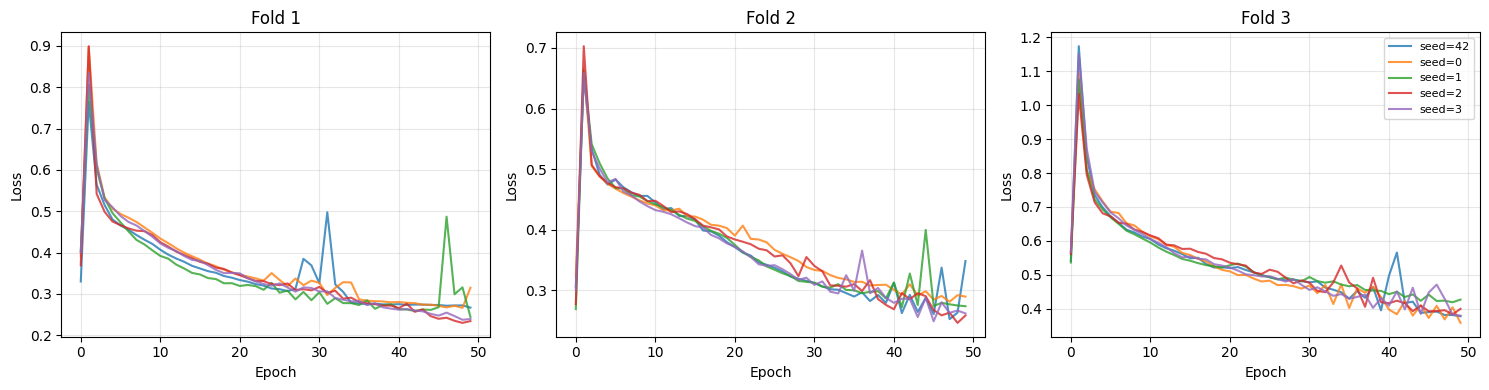

In [19]:
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for fold_idx in range(3):
        ax = axes[fold_idx]
        for result in all_results:
            seed = result["seed"]
            loss_history = result["fold_metrics"][fold_idx].get("loss_history", [])
            if loss_history:
                ax.plot(loss_history, label=f"seed={seed}", alpha=0.8)
        ax.set_title(f"Fold {fold_idx + 1}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.grid(True, alpha=0.3)

    axes[-1].legend(fontsize=8)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("matplotlib is not installed. Install it if you want plots.")